## Install or Import Packages

In [1]:
# Install grad-cam package (only for this notebook)
%pip install grad-cam

Note: you may need to restart the kernel to use updated packages.


In [2]:
%cd ..

/common/wut4/workspace/OCT


In [3]:
import os, torch
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
import pandas as pd

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

from model import ResNetClassifier
from dataloader import data_collector, data_split, get_data_transforms

In [65]:
# df = pd.read_csv('./grafted/225/grafted_result_225.csv')
df = pd.read_csv('./grafted/1000/grafted_result_1000.csv')

In [67]:
df['group'] = df['path'].apply(lambda x: x.split('/')[4])
df['ID'] = df['path'].apply(lambda x: x.split('/')[5].split('_')[0])
df['image'] = df['path'].apply(lambda x: int(x.split('/')[-1].split('_')[-1].split('.')[0]))

In [68]:
df

,Unnamed: 0,path,pred,group,ID,image
0,0,./data/OCT-Tiff/Grafted eyes/400K P60/G401_OD_...,3,400K P60,G401,1
1,1,./data/OCT-Tiff/Grafted eyes/400K P60/G401_OD_...,3,400K P60,G401,2
2,2,./data/OCT-Tiff/Grafted eyes/400K P60/G401_OD_...,3,400K P60,G401,3
3,3,./data/OCT-Tiff/Grafted eyes/400K P60/G401_OD_...,3,400K P60,G401,4
4,4,./data/OCT-Tiff/Grafted eyes/400K P60/G401_OD_...,3,400K P60,G401,5
...,...,...,...,...,...,...
11895,11895,./data/OCT-Tiff/Grafted eyes/60K P90/G310_OD_V...,4,60K P90,G310,346
11896,11896,./data/OCT-Tiff/Grafted eyes/60K P90/G310_OD_V...,4,60K P90,G310,347
11897,11897,./data/OCT-Tiff/Grafted eyes/60K P90/G310_OD_V...,4,60K P90,G310,348
11898,11898,./data/OCT-Tiff/Grafted eyes/60K P90/G310_OD_V...,4,60K P90,G310,349


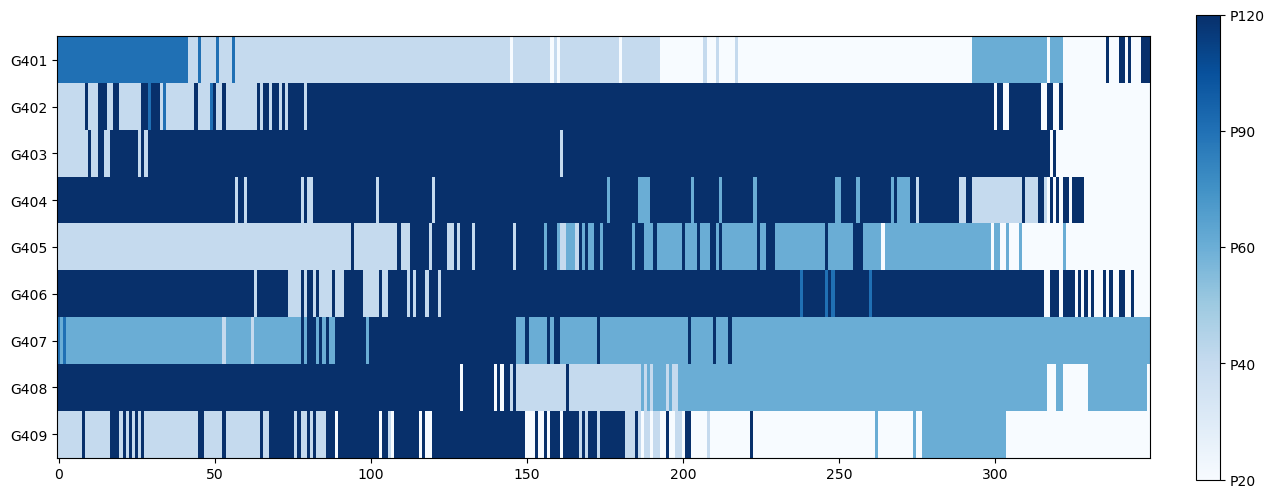

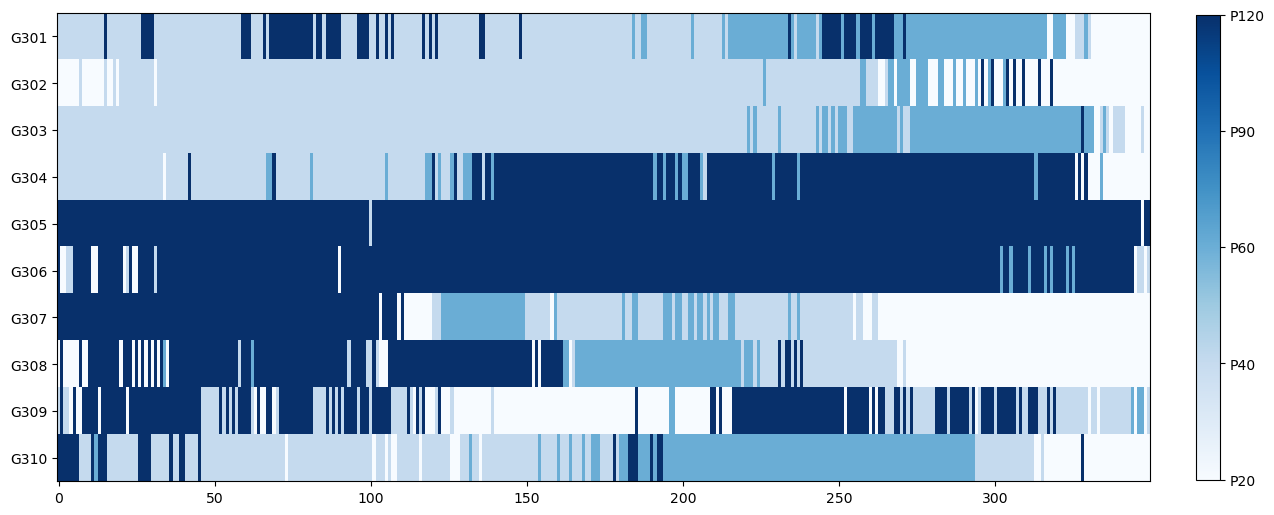

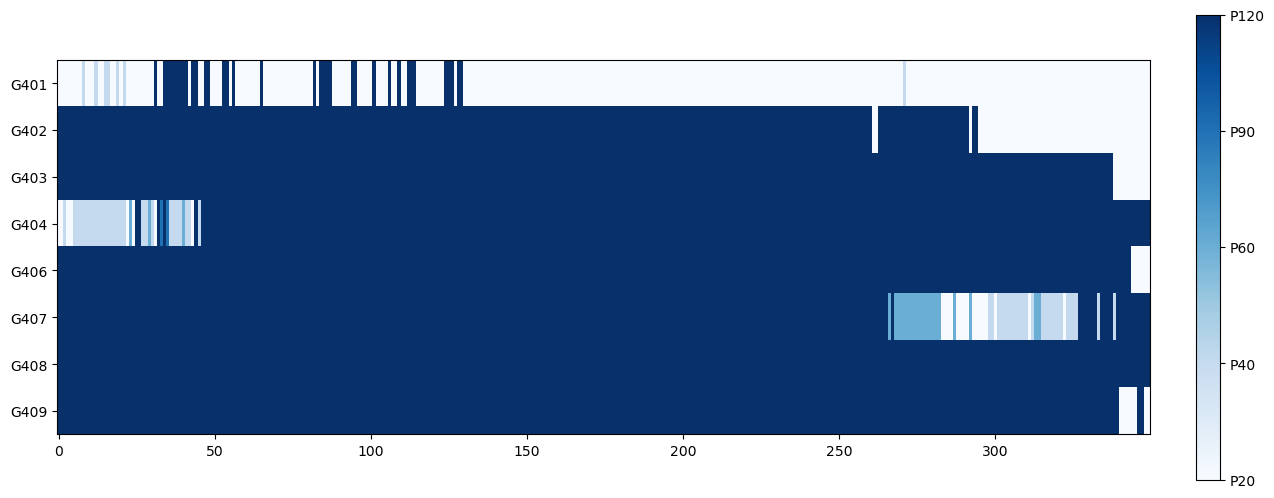

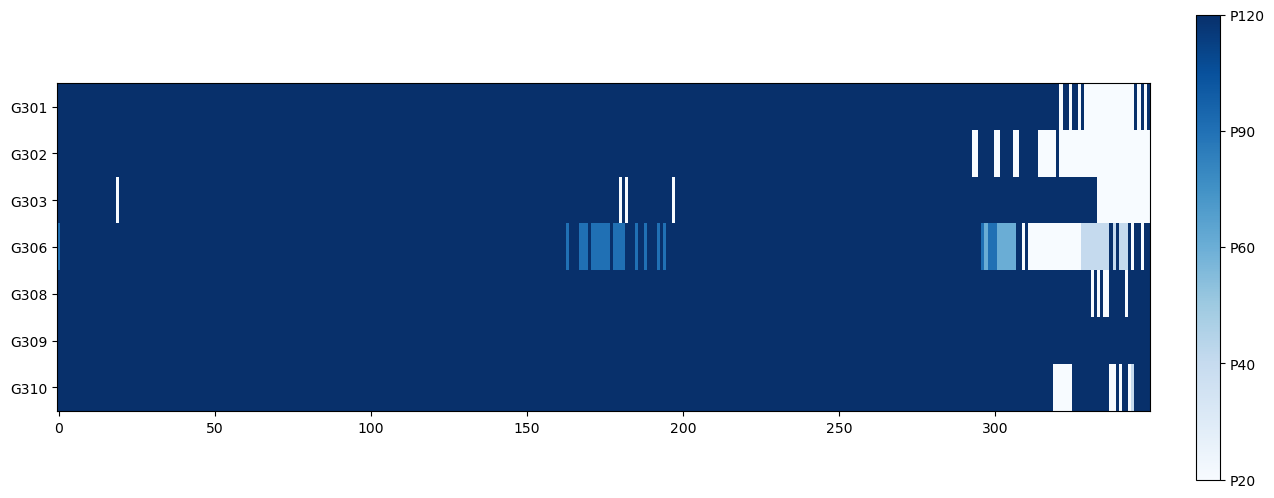

In [69]:
for group in set(list(df['group'])):
    sub_df = df[df['group'] == group]
    ID_list = sorted(list(set(list(sub_df['ID']))))
    n_ID = len(ID_list)

    pred = np.zeros((350, n_ID))
    
    for idx, ID in enumerate(ID_list):
        single_df = sub_df[sub_df['ID'] == ID].sort_values(by='image')
        pred[:, idx] = single_df['pred']

    plt.figure(figsize=(15, n_ID))
    plt.imshow(pred.T, aspect=15, interpolation="none",cmap="Blues")
    plt.yticks(range(n_ID), ID_list)
    
    cbar = plt.colorbar(fraction=0.02, pad=0.04)
    cbar.set_ticks(np.arange(5))
    cbar.set_ticklabels(['P20', 'P40', 'P60', 'P90', 'P120'])
    plt.savefig(f"grafted_{group.replace(' ', '_')}.png")

## Load Model

In [78]:
# 1000x1000
# save_dir = os.path.join('results', '20240321-194738')
# input_shape = 1000
# 225x225
save_dir = os.path.join('results', '20240321-195954')
input_shape = 225

In [79]:
model = ResNetClassifier(num_classes=5)
model = model.load_from_checkpoint(os.path.join(save_dir, 'bestmodel.ckpt'), map_location=torch.device('cpu'))
model.eval()

ResNetClassifier(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, t

In [80]:
# target layer for ResNet 18
target_layers = [model.resnet.layer4[-1]]

In [81]:
cam = GradCAM(model=model, target_layers=target_layers)

## Load Data

In [82]:
sub_df = df[(df['group'] == '400K P90') & (df['ID'] == 'G401')]

In [83]:
img_path = sub_df['path'].values[150]

In [84]:
data_transforms = get_data_transforms(input_shape=(input_shape, input_shape))['val']

image = Image.open(img_path)
X = data_transforms(image).unsqueeze(0)

Data information: need to justify if this is a correct case

In [86]:
output = model(X)
pred = np.argmax(output.detach().numpy())
print(f"Prediction: {pred}, output: {output}")

Prediction: 0, output: tensor([[ 9.2994,  0.3820, -2.0135, -6.7162, -6.2373]],
       grad_fn=<AddmmBackward0>)


In [87]:
grayscal_cam = cam(input_tensor=X, targets=None)

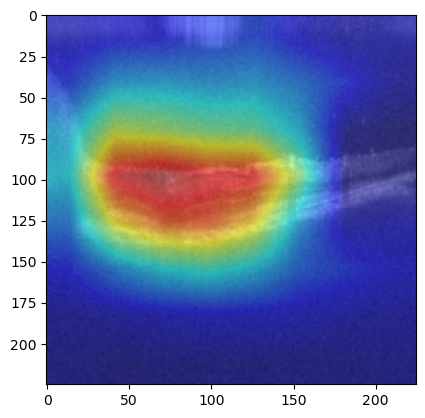

In [88]:
visualization = show_cam_on_image(np.transpose(X[0].numpy(), (1, 2, 0)), grayscal_cam[0], use_rgb=True)
plt.imshow(visualization)

In [91]:
plt.imsave(f"{img_path.split('/')[-1].replace('TIFF', '')}_gradcam.png", visualization)

In [109]:
plt.imsave(f"{img_path.split('/')[-1].replace('TIFF', 'png')}", X.numpy()[0, :, :, :].transpose(1, 2, 0))